In [1]:
import json
import pandas as pd
from pymongo import MongoClient, UpdateOne
from datetime import datetime

# ====== 1. Connect to MongoDB (UPDATED) ======
client = MongoClient("mongodb://localhost:27017")
db = client["New_Sentiment_DB_V2"]              # <--- UPDATED Database name
collection = db["Articles_V2"]                  # <--- UPDATED Collection name

# ====== 2. Load your JSON file (UPDATED) ======
file_path = "a_newdata.json"                    # <--- File path updated 
try:
    with open(file_path, "r") as f:
        data = json.load(f)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is in the correct directory.")
    # Exit or handle the error as appropriate
    # return
    
print("Loaded", len(data), "records from JSON file.")

# Create DataFrame for initial inspection
df = pd.DataFrame(data)
print(df.head())

Loaded 249998 records from JSON file.
                                               title  \
0  Alphabet Inc. (GOOGL) shares gain 0.5% on earn...   
1  Meta Platforms Inc. Threads progresses in mark...   
2  Meta Platforms Inc. Quest VR faces challenges ...   
3  Analysts maintain AAPL following Apple Inc. co...   
4  Tesla Inc. (TSLA) shares gain 3.9% on product ...   

                                         description  \
0  Alphabet Inc. (GOOGL) shares gain 0.5% on earn...   
1  Meta Platforms Inc. Threads progresses in mark...   
2  Meta Platforms Inc. Quest VR faces challenges ...   
3  Analysts maintain AAPL following Apple Inc. co...   
4  Tesla Inc. (TSLA) shares gain 3.9% on product ...   

                                             content published_at  \
0  Alphabet Inc.'s return on invested capital of ...     1/1/2024   
1  Meta Platforms Inc. (META) demonstrated strate...     1/1/2024   
2  Manufacturing capacity expansion at Meta Platf...     1/1/2024   
3  Apple Inc

In [2]:
# ====== 3. Insert into MongoDB ======
# Clear existing documents in the collection before inserting the new data 
# to ensure the cleaning/aggregation process starts fresh with the new file's content.
collection.delete_many({}) # Clears out any old data in Articles_V2
result = collection.insert_many(data) # Inserts all records from a_newdata.json

print("Inserted", len(result.inserted_ids), "documents into MongoDB.")

Inserted 249998 documents into MongoDB.


In [3]:
# ====== 4. Clean and Normalize ======

BATCH_SIZE = 1000

def parse_published_at(value):
    """Parse publishedAt into a datetime (format: MM/DD/YYYY)."""
    if isinstance(value, datetime):
        return value
    if isinstance(value, str):
        try:
            return datetime.strptime(value, "%m/%d/%Y")
        except ValueError:
            return None
    return None


updated_count = 0
bulk_ops = []

# Fetch all documents to apply updates
cursor = collection.find({}, batch_size=BATCH_SIZE)

for doc in cursor:
    set_fields = {}
    unset_fields = {}

    # 1) publishedAt → published_at (datetime)
    if "publishedAt" in doc:
        new_dt = parse_published_at(doc["publishedAt"])
        if new_dt is not None:
            set_fields["published_at"] = new_dt
        unset_fields["publishedAt"] = ""

    # 2) company_name → company
    if "company_name" in doc:
        set_fields["company"] = doc["company_name"]
        unset_fields["company_name"] = ""

    # 3A) sentiment → sentiment_score
    if "sentiment" in doc:
        try:
            score = float(doc["sentiment"])
            set_fields["sentiment_score"] = score
        except (ValueError, TypeError):
            set_fields["sentiment_score"] = None
        unset_fields["sentiment"] = ""

    # 3B) sentiment_score exists but is STRING → convert to float
    if isinstance(doc.get("sentiment_score"), str):
        try:
            score = float(doc["sentiment_score"])
            set_fields["sentiment_score"] = score
        except (ValueError, TypeError):
            set_fields["sentiment_score"] = None
    
    # Handle cases where published_at might be missing after parsing
    if "published_at" not in set_fields and doc.get("published_at") is None:
        # If published_at is None, we should keep it and let the aggregation step handle the missing date.
        pass

    # If there are changes, add an update operation
    if set_fields or unset_fields:
        update_doc = {}
        if set_fields:
            update_doc["$set"] = set_fields
        if unset_fields:
            update_doc["$unset"] = unset_fields

        bulk_ops.append(UpdateOne({"_id": doc["_id"]}, update_doc))

    # Execute in batches
    if len(bulk_ops) >= BATCH_SIZE:
        result_batch = collection.bulk_write(bulk_ops, ordered=False)
        updated_count += result_batch.modified_count
        print("Updated so far:", updated_count)
        bulk_ops = []

# Flush remaining
if bulk_ops:
    result_batch = collection.bulk_write(bulk_ops, ordered=False)
    updated_count += result_batch.modified_count

print("Total documents modified:", updated_count)

Updated so far: 1000
Updated so far: 2000
Updated so far: 3000
Updated so far: 4000
Updated so far: 5000
Updated so far: 6000
Updated so far: 7000
Updated so far: 8000
Updated so far: 9000
Updated so far: 10000
Updated so far: 11000
Updated so far: 12000
Updated so far: 13000
Updated so far: 14000
Updated so far: 15000
Updated so far: 16000
Updated so far: 17000
Updated so far: 18000
Updated so far: 19000
Updated so far: 20000
Updated so far: 21000
Updated so far: 22000
Updated so far: 23000
Updated so far: 24000
Updated so far: 25000
Updated so far: 26000
Updated so far: 27000
Updated so far: 28000
Updated so far: 29000
Updated so far: 30000
Updated so far: 31000
Updated so far: 32000
Updated so far: 33000
Updated so far: 34000
Updated so far: 35000
Updated so far: 36000
Updated so far: 37000
Updated so far: 38000
Updated so far: 39000
Updated so far: 40000
Updated so far: 41000
Updated so far: 42000
Updated so far: 43000
Updated so far: 44000
Updated so far: 45000
Updated so far: 460

In [4]:
# ====== 5. Create Daily Aggregation ======

articles = collection                          # Source collection: Articles_V2
daily = db["daily_company_sentiment_v2"]       # <--- UPDATED Aggregation collection name

# This MUST be unique: one row per company per date
daily.create_index(
    [("company", 1), ("date", 1)],
    unique=True
)

print("Index created.")

pipeline = [
    {
        "$project": {
            "company": 1,
            "sentiment_score": 1,
            # Ensure published_at is a Date object (handles potential string issues from prior steps)
            "date_obj": {
                "$dateFromString": {
                    "dateString": "$published_at",
                    "format": "%m/%d/%Y",
                    "onError": None 
                }
            }
        }
    },
    {
        "$project": {
            "company": 1,
            "sentiment_score": 1,
            # Use the newly created date_obj for truncation
            "date": {
                "$dateTrunc": {
                    "date": "$date_obj",
                    "unit": "day"
                }
            }
        }
    },
    {
        "$group": {
            "_id": {
                "company": "$company",
                "date": "$date"
            },
            "avg_score": {"$avg": "$sentiment_score"},
            "article_count": {"$sum": 1}
        }
    },
    {
        "$project": {
            "_id": 0,
            "company": "$_id.company",
            "date": "$_id.date",
            "avg_score": 1,
            "article_count": 1
        }
    },
    {
        "$merge": {
            "into": "daily_company_sentiment_v2",   # <--- UPDATED Target collection name
            "on": ["company", "date"],            
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

# Execute the aggregation
result = list(articles.aggregate(pipeline))
print("Aggregation finished.")
print("Daily collection now:", daily.estimated_document_count())
days = daily.distinct("date")
print("Number of unique days:", len(days))

Index created.
Aggregation finished.
Daily collection now: 4858
Number of unique days: 694


                        _id  avg_score  article_count                company  \
0  692bc8341e38c4d0d8feeec0   0.544434             56             Apple Inc.   
1  692bc8341e38c4d0d8feee16   0.558379             42        Amazon.com Inc.   
2  692bc8341e38c4d0d8fef4af   0.506205             59  Microsoft Corporation   
3  692bc8341e38c4d0d8fefc02   0.436500             45     NVIDIA Corporation   
4  692bc8341e38c4d0d8fefb3f   0.474792             63    Meta Platforms Inc.   
5  692bc8341e38c4d0d8fef36d   0.418134             53             Tesla Inc.   
6  692bc8341e38c4d0d8fef147   0.489097             71          Alphabet Inc.   

        date  
0 2024-01-01  
1 2024-01-01  
2 2024-01-01  
3 2024-01-01  
4 2024-01-01  
5 2024-01-01  
6 2024-01-01  
                 company  avg_sentiment
0          Alphabet Inc.       0.489097
1        Amazon.com Inc.       0.558379
2             Apple Inc.       0.544434
3    Meta Platforms Inc.       0.474792
4  Microsoft Corporation       0.506205

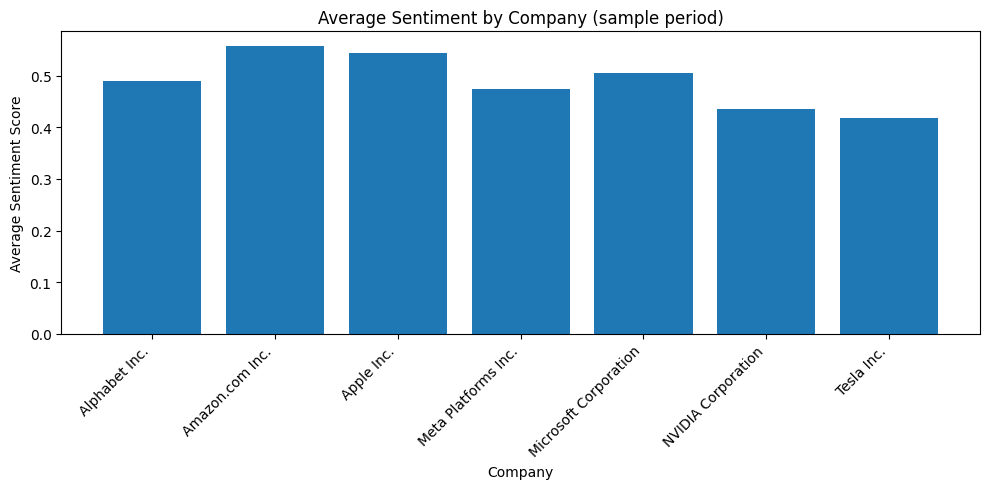

In [5]:
# ====== 6. Visualize ======
import matplotlib.pyplot as plt 

# Display first 7 documents from the 'daily' collection
# This step loads only a small sample (7 days) into the DataFrame.
docs_daily = list(daily.find().sort("date", 1).limit(7))
df_daily = pd.DataFrame(docs_daily)

print(df_daily.head(7)) # Corrected to print the 7 documents loaded

# Summarize average sentiment and total articles by company (based on the limited sample)
# NOTE: This calculates the UNWEIGHTED mean, as previously discussed.
company_summary = df_daily.groupby("company").agg(
    avg_sentiment=("avg_score", "mean"),
).reset_index()

print(company_summary)

# Plotting the summary (Bar Chart of Unweighted Averages)
plt.figure(figsize=(10, 5))
plt.bar(company_summary["company"], company_summary["avg_sentiment"])
plt.xlabel("Company")
plt.ylabel("Average Sentiment Score")
plt.title("Average Sentiment by Company (sample period)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Loaded 4858 daily records. Preparing plot...


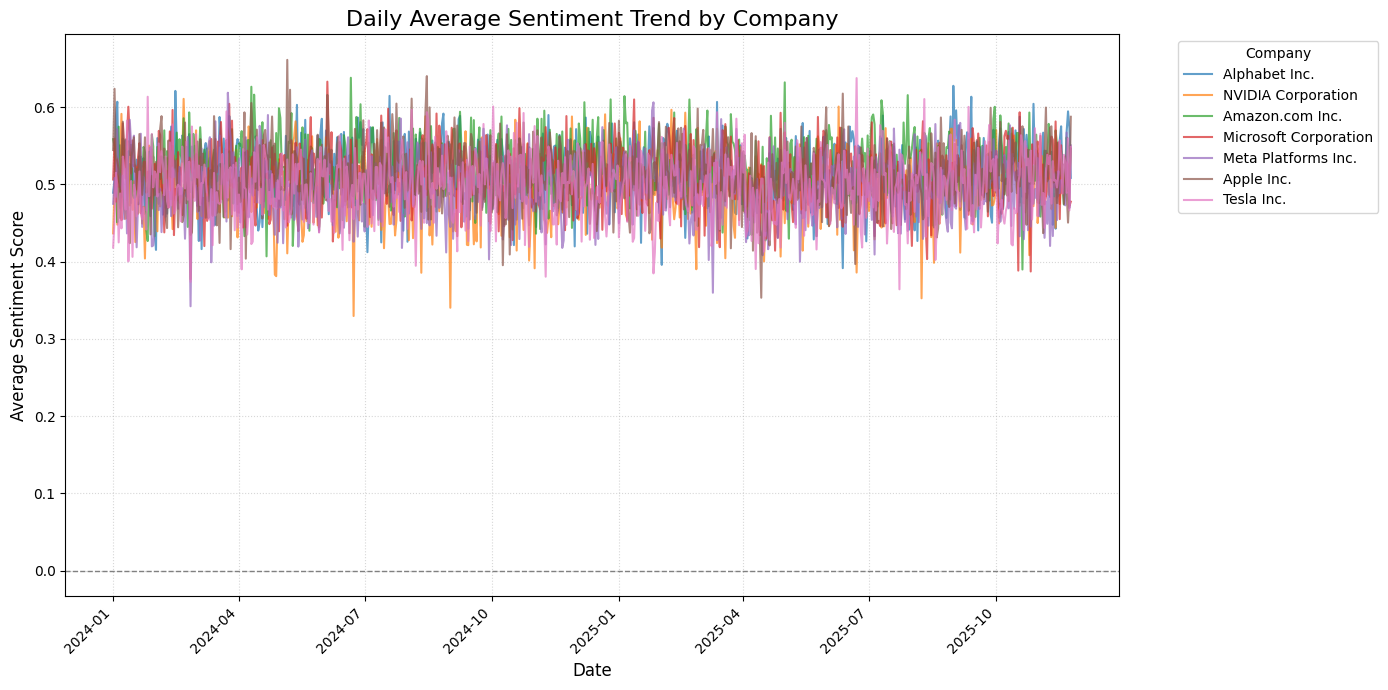

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

daily_data = list(daily.find().sort("date", 1))

if not daily_data:
    print("The 'daily_company_sentiment_new' collection is empty. Please ensure your aggregation finished successfully.")
else:
    # --- 3. Create the pandas DataFrame ---
    df_daily_full = pd.DataFrame(daily_data)
    
    # Ensure the date column is in datetime format for accurate plotting
    df_daily_full["date"] = pd.to_datetime(df_daily_full["date"])

    print(f"Loaded {len(df_daily_full)} daily records. Preparing plot...")

    # --- 4. Plot the Daily Sentiment Trend ---
    plt.figure(figsize=(14, 7))

    # Use seaborn lineplot for the trend, using avg_score against date, grouped by company
    sns.lineplot(
        data=df_daily_full, 
        x="date", 
        y="avg_score", 
        hue="company", 
        marker=None, # Remove markers for a cleaner daily trend
        alpha=0.7 
    )

    # --- Formatting the plot ---
    plt.title("Daily Average Sentiment Trend by Company", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Average Sentiment Score", fontsize=12)
    
    # Add a horizontal line at 0.0 for reference (neutral sentiment)
    plt.axhline(0.0, color='gray', linestyle='--', linewidth=1)
    
    # Improve x-axis date visibility
    plt.xticks(rotation=45, ha='right')
    
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()